# M/G/1 scheduling disciplines: the big comparison

One server, the same arrival stream and the same job-size distribution — only the **scheduling
discipline** changes. We compare everything the library implements:

| Discipline | Knows size? | Preemptive? | Class |
|---|---|---|---|
| FCFS | no | no | `MG1Calc` |
| PS (Processor Sharing) | no | shares the server | `MG1PSCalc` |
| LCFS-PR | no | yes (stack) | `MG1LcfsPrCalc` |
| FB (LAS) | no | yes, by attained service | `MG1FbCalc` |
| SJF | yes | no | `MG1SjfCalc` |
| PSJF | yes | yes, by original size | `MG1PsjfCalc` |
| SRPT | yes | yes, by remaining size | `MG1SrptCalc` |
| SPJF | prediction | no | `MG1SpjfCalc` |

Detailed model descriptions are in [docs/models.md](../docs/models.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from most_queue.random.distributions import GammaDistribution
from most_queue.theory.fifo.mg1 import MG1Calc
from most_queue.theory.fifo.mg1_ps import MG1PSCalc
from most_queue.theory.fifo.mg1_lcfs_pr import MG1LcfsPrCalc
from most_queue.theory.srpt import (
    MG1FbCalc, MG1SjfCalc, MG1PsjfCalc, MG1SrptCalc, MG1SpjfCalc,
    ExpNoisePredictor, PerfectPredictor,
)

LAM = 1.0            # arrival rate
MEAN, CV = 0.7, 1.5  # mean and CV of the job size
RHO = LAM * MEAN

gamma_params = GammaDistribution.get_params_by_mean_and_cv(MEAN, CV)
b = GammaDistribution.calc_theory_moments(gamma_params, 5)
print(f"rho = {RHO:.2f}, b1 = {b[0]:.3f}, cv = {CV}")

rho = 0.70, b1 = 0.700, cv = 1.5

## Mean sojourn times

We compute $E[V]$ for each discipline. For LCFS-PR we also look at the second moment — its *mean* is
the same as FCFS and PS, but its spread is completely different.

In [2]:
def size_based(cls, predictor=None):
    calc = cls()
    calc.set_sources(LAM)
    calc.set_servers(gamma_params, "Gamma")
    if predictor is not None:
        calc.set_predictor(predictor)
    return calc.run()

fcfs = MG1Calc(); fcfs.set_sources(l=LAM); fcfs.set_servers(b)
fcfs_res = fcfs.run()

ps = MG1PSCalc(); ps.set_sources(l=LAM); ps.set_servers(b)
ps_res = ps.run()

lcfs = MG1LcfsPrCalc(); lcfs.set_sources(l=LAM); lcfs.set_servers(b)
lcfs_res = lcfs.run()

results = {
    "FCFS": fcfs_res.v[0],
    "PS": ps_res.v[0],
    "LCFS-PR": lcfs_res.v[0],
    "FB (LAS)": size_based(MG1FbCalc).v[0],
    "SJF": size_based(MG1SjfCalc).v[0],
    "PSJF": size_based(MG1PsjfCalc).v[0],
    "SRPT": size_based(MG1SrptCalc).v[0],
    "SPJF (perfect)": size_based(MG1SpjfCalc, PerfectPredictor()).v[0],
    "SPJF (noisy prediction)": size_based(MG1SpjfCalc, ExpNoisePredictor()).v[0],
}

df = pd.DataFrame(
    {"E[V]": results.values()}, index=results.keys()
).sort_values("E[V]")
df["vs FCFS"] = df["E[V]"] / results["FCFS"]
df.round(3)

/home/roman/pyprojects/most-queue-git/most-queue/most_queue/theory/srpt/utils/predictor.py:89: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  value, _ = quad(lambda x: service_pdf_fn(x) * self._cond_pdf(y, x), 0.0, math.inf, limit=400)


,E[V],vs FCFS
SRPT,1.296,0.386
PSJF,1.430,0.426
SJF,1.939,0.578
SPJF (perfect),1.940,0.578
SPJF (noisy prediction),2.138,0.638
FB (LAS),2.189,0.653
LCFS-PR,2.333,0.696
PS,2.333,0.696
FCFS,3.354,1.000


In [3]:
cv_sojourn_fcfs = np.sqrt(fcfs_res.v[1] - fcfs_res.v[0] ** 2) / fcfs_res.v[0]
cv_sojourn_lcfs = np.sqrt(lcfs_res.v[1] - lcfs_res.v[0] ** 2) / lcfs_res.v[0]
print(f"E[V]: PS = {ps_res.v[0]:.3f},  LCFS-PR = {lcfs_res.v[0]:.3f} (equal: b1/(1-rho), insensitivity)")
print(f"E[V] FCFS = {fcfs_res.v[0]:.3f} - also depends on b2 (Pollaczek-Khinchine)")
print(f"sojourn-time CV: FCFS = {cv_sojourn_fcfs:.2f},  LCFS-PR = {cv_sojourn_lcfs:.2f}")

E[V]: PS = 2.333,  LCFS-PR = 2.333 (equal: b1/(1-rho), insensitivity)

E[V] FCFS = 3.354 - also depends on b2 (Pollaczek-Khinchine)

sojourn-time CV: FCFS = 1.15,  LCFS-PR = 3.14

## Who pays: slowdown by job size

Averages hide the main story — *whom* a discipline helps and whom it punishes. We look at the
conditional slowdown $E[T(x)]/x$ (response time per unit of work, as a function of job size $x$).

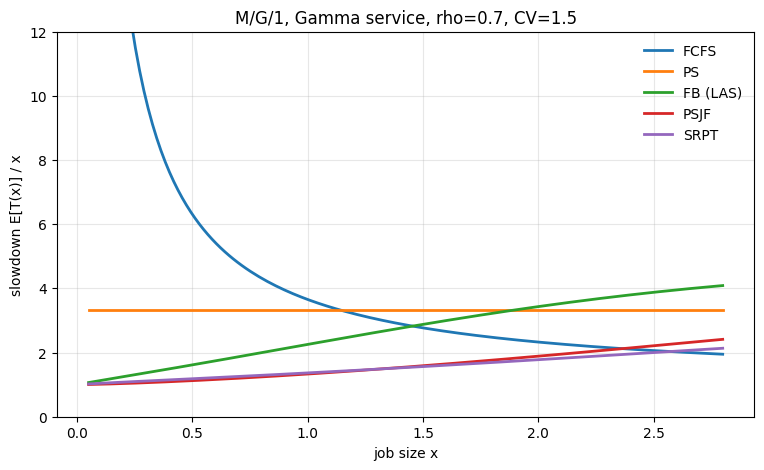

In [4]:
fb = MG1FbCalc(); fb.set_sources(LAM); fb.set_servers(gamma_params, "Gamma"); fb.run()
srpt = MG1SrptCalc(); srpt.set_sources(LAM); srpt.set_servers(gamma_params, "Gamma"); srpt.run()
psjf = MG1PsjfCalc(); psjf.set_sources(LAM); psjf.set_servers(gamma_params, "Gamma"); psjf.run()

xs = np.linspace(0.05, 4 * MEAN, 150)
curves = {
    "FCFS": [(fcfs_res.w[0] + x) / x for x in xs],
    "PS": [1 / (1 - RHO)] * len(xs),
    "FB (LAS)": [fb.conditional_mean_response(float(x)) / x for x in xs],
    "PSJF": [psjf.conditional_mean_response(float(x)) / x for x in xs],
    "SRPT": [srpt.conditional_mean_response(float(x)) / x for x in xs],
}

fig, ax = plt.subplots(figsize=(9, 5))
for name, ys in curves.items():
    ax.plot(xs, ys, lw=2, label=name)
ax.set_ylim(0, 12)
ax.set_xlabel("job size x")
ax.set_ylabel("slowdown E[T(x)] / x")
ax.set_title(f"M/G/1, Gamma service, rho={RHO:.1f}, CV={CV}")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

## Validation by simulation

Every calculator in the library ships with a paired simulator. We check a couple of disciplines
here (the test suite `tests/` does this for all of them).

In [5]:
from most_queue.sim.single_server_disciplines import FBSim, ProcessorSharingSim

sim_fb = FBSim()
sim_fb.set_sources(LAM, "M")
sim_fb.set_servers(gamma_params, "Gamma")
fb_sim_res = sim_fb.run(100_000)

sim_ps = ProcessorSharingSim()
sim_ps.set_sources(LAM, "M")
sim_ps.set_servers(gamma_params, "Gamma")
ps_sim_res = sim_ps.run(100_000)

print(f"FB:  theory {results['FB (LAS)']:.3f}, simulation {fb_sim_res.v[0]:.3f}")
print(f"PS:  theory {results['PS']:.3f}, simulation {ps_sim_res.v[0]:.3f}")

FB:  theory 2.189, simulation 2.129

PS:  theory 2.333, simulation 2.331

## Takeaways

1. **SRPT is optimal for the mean**: it minimizes $E[V]$ over *all* disciplines; PSJF and SJF are
   close but worse.
2. **Knowing sizes can be replaced by predicting them**: SPJF with a perfect predictor equals SJF;
   with a noisy predictor the gain is partly retained (how much depends on prediction quality — see
   the graceful-degradation analysis in the SRPT docs).
3. **Blind disciplines can win too**: FB, without knowing sizes, beats PS and FCFS when CV > 1,
   because short jobs statistically finish sooner.
4. **The mean is not the whole truth**: PS and LCFS-PR have the *same* $E[V] = b_1/(1-\rho)$ for any
   service distribution (insensitivity), but completely different tails (see the sojourn-time CV).
   FCFS has a different mean — it also depends on the second moment $b_2$ (Pollaczek–Khinchine), so
   for CV > 1 FCFS loses even to "blind" preemptive disciplines.

References: Schrage–Miller (1966), Kleinrock (1967), Nuyens–Wierman (2008), Mitzenmacher (2020),
Harchol-Balter *Performance Modeling and Design of Computer Systems* (2013). DOIs are in the
calculator docstrings and [docs/models.md](../docs/models.md).